# Create figures 3 and 4

In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import altair as alt

### Load in data:

In [2]:
sierras = gpd.read_file('../../data/misc/sierra_simplified.geojson')

In [3]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_22Oct2025_masked_lowslope.pkl', 'rb'))

In [4]:
atl06sr_gdf['n'] = atl06sr_gdf.groupby('acqdate')['acqdate'].transform('count')

In [5]:
atl06sr_gdf = atl06sr_gdf[atl06sr_gdf['n']>100]

In [7]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../../analog_snowmapping/swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Compute the mask for the snowy region:

In [8]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../../analog_snowmapping/swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [9]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) )).compute()


In [10]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1_mean = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True).compute()

In [11]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1_mean.SCA_Post > 0.5

In [16]:
swe_sca_ds_roi = swe_sca_ds_allyrs.where(mask)

### Calculate daily median snow depth throughout the Sierra Nevada within the snowy region:

In [17]:
# 5. Compute spatial median
median_sd = swe_sca_ds_roi.SD_Post.median(dim=('y', 'x'), skipna=True).compute()

In [19]:
# Calculate 10-day rolling medians of median_sd using calendar time windows
# Convert to pandas Series for time-based rolling (xarray doesn't support string windows)
sd_values = median_sd.values
sd_times = pd.to_datetime(median_sd['time'].values)
sd_series = pd.Series(sd_values, index=sd_times)

# Pre-convert datetime index to int64 for rolling median of time dimension
sd_times_int = pd.Series(sd_times.astype(np.int64), index=sd_times)

# 10-day rolling median
sd_rolling_10days = sd_series.rolling(window='10D', center=True, min_periods=1).median()
sd_rolling_10days_date = pd.to_datetime(
    sd_times_int.rolling(window='10D', center=True, min_periods=1).median()
)

sd_rolling_10days_df = pd.DataFrame({
    'date': sd_rolling_10days_date,
    'sd_rolling_10days': sd_rolling_10days.values
})
sd_rolling_10days_df

,date,sd_rolling_10days
1984-10-01,1984-10-03 12:00:00,0.0
1984-10-02,1984-10-04 00:00:00,0.0
1984-10-03,1984-10-04 12:00:00,0.0
1984-10-04,1984-10-05 00:00:00,0.0
1984-10-05,1984-10-05 12:00:00,0.0
...,...,...
2021-09-26,2021-09-26 00:00:00,0.0
2021-09-27,2021-09-26 12:00:00,0.0
2021-09-28,2021-09-27 00:00:00,0.0
2021-09-29,2021-09-27 12:00:00,0.0


### Calculate the median snow depth on each ICESat-2 acquisition date:

In [21]:
medians_both = atl06sr_gdf.loc[(atl06sr_gdf['n']>100), ['icesat2_3dep_dif', 'reanalysis_sd','acqdate']].dropna().groupby('acqdate').median()

In [22]:
medians_both['date'] = pd.to_datetime(medians_both.index)

In [23]:
# Calculate 10-day running median using calendar time (not row count)
# Set date as index for proper time-based rolling
medians_temp = medians_both.set_index('date')

medians_temp['running_median_10days'] = medians_temp['icesat2_3dep_dif'].rolling(
    window='10D', 
    center=True,
    min_periods=1  # Allow calculation even with fewer data points in window
).median()

# Calculate median date within each window using numeric conversion
medians_temp['running_median_10days_date'] = pd.to_datetime(
    medians_temp.index.to_series().astype(np.int64).rolling(
        window='10D',
        center=True,
        min_periods=1
    ).median()
)

medians_both['running_median_10days'] = medians_temp['running_median_10days']
medians_both['running_median_10days_date'] = medians_temp['running_median_10days_date']

### Plot boxplots to show ICESat-2 spread on acquisition dates relative to domain-wide median:

In [27]:
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
from matplotlib.ticker import FuncFormatter
import datetime
from matplotlib.lines import Line2D

mpl_epoch = '1970-01-01'

In [25]:
highlight_dates = ['2019-03-16','2020-04-11','2021-04-01'] 
highlight_dates_dt = pd.to_datetime(highlight_dates)

In [30]:
# Function adapted from David Shean by Hannah Besso
# Allows for multiple levels of data to be plotted. Can just plot in situ snow depth, or can add any/all of the following:
# ICESat-2, sampled ASO, and full-site ASO

def boxplot_timeseries_highlights(df=None, col=None, col2=None, groupby_col='acqdate', highlights=None,
                         title='Sierras Median Snow Depth', name='../figures/boxplots_cdec_aso.jpeg', 
                         main_color=None, main_color_median=None,highlight_color=None, main_color2=None, highlight_color2=None, clim=(-2, 5)):
    
    df_nh = df[~df['acqdate_dt'].isin(highlights)]
    df_h = df[df['acqdate_dt'].isin(highlights)]

    # ATL06 stats
    if df is not None:
        bp_stats_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_nh = [i[0] for i in bp_stats_nh.values]
        bp_alpha_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_nh = bp_alpha_nh/bp_alpha_nh.max()
        pos_nh = (pd.to_datetime(bp_stats_nh.index) - pd.to_datetime(mpl_epoch)).days.values

    if col2 is not None:
        bp_stats_nh2 = df_nh[[col2, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_nh2 = [i[0] for i in bp_stats_nh2.values]
        bp_alpha_nh2 = df_nh[[col2, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_nh2 = bp_alpha_nh2/bp_alpha_nh2.max()
        pos_nh2 = (pd.to_datetime(bp_stats_nh2.index) - pd.to_datetime(mpl_epoch)).days.values

    if highlights is not None:
        bp_stats_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_h = [i[0] for i in bp_stats_h.values]
        bp_alpha_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_h = bp_alpha_h/bp_alpha_h.max()
        pos_h = (pd.to_datetime(bp_stats_h.index) - pd.to_datetime(mpl_epoch)).days.values
    
    if (highlights is not None) & (col2 is not None):
        bp_stats_h2 = df_h[[col2, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_h2 = [i[0] for i in bp_stats_h2.values]
        bp_alpha_h2 = df_h[[col2, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_h2 = bp_alpha_h2/bp_alpha_h2.max()
        pos_h2 = (pd.to_datetime(bp_stats_h2.index) - pd.to_datetime(mpl_epoch)).days.values
    
    f, ax = plt.subplots(figsize=(15,7))
    
    median_sd.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)', color='k', linewidth=1)
    
    # Plot ATL06 data
    if (df is not None) & (main_color_median is not None):
        bxp_f_nh = ax.bxp(bp_stats_list_nh, positions=pos_nh, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color},  
                   medianprops={'lw':3, 'color':main_color_median},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh['boxes'], bp_alpha_boxes_nh):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    if (df is not None) & (main_color_median is None):
        bxp_f_nh = ax.bxp(bp_stats_list_nh, positions=pos_nh, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color},  
                   medianprops={'lw':3, 'color':main_color},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh['boxes'], bp_alpha_boxes_nh):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    if col2 is not None:
        bxp_f_nh2 = ax.bxp(bp_stats_list_nh2, positions=pos_nh2, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color2},  
                   medianprops={'lw':3, 'color':main_color},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh2['boxes'], bp_alpha_boxes_nh2):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

       # Plot highlight data
    if highlights is not None:
        bxp_f_h = ax.bxp(bp_stats_list_h, positions=pos_h, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.5, 'facecolor':highlight_color},  
                   medianprops={'lw':3, 'color':highlight_color},widths=10, patch_artist=True, zorder=2)
        for patch, alpha in zip(bxp_f_h['boxes'], bp_alpha_boxes_h):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    if (highlights is not None) & (col2 is not None):
        bxp_f_h2 = ax.bxp(bp_stats_list_h2, positions=pos_h2, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.5, 'facecolor':highlight_color2},  
                   medianprops={'lw':3, 'color':highlight_color2},widths=10, patch_artist=True, zorder=2)
        for patch, alpha in zip(bxp_f_h2['boxes'], bp_alpha_boxes_h2):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    ax.set_title(title, fontsize=24)
    
    
    #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    #         patch.set_edgecolor('None')
    #         patch.set_linewidth(0)
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    #         patch.set_color('k')  # or deeppink  
    
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Snow Depth (m)', fontsize=22)
    ax.set_ylim(*clim)
    ax.set_xlim([dt_min_plot, dt_max_plot])
    
    
    # X AXIS LABELS     
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    
    def m_fmt(x, pos=None):
        return month_fmt(x)[0]
    
    ax.xaxis.set_minor_locator(months) 
    ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
    
    years = mdates.MonthLocator(bymonth=1)
    ax.format_xdata = mdates.DateFormatter('%Y')
    years_fmt = mdates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.tick_params('both', length=5, width=1.5, which='major')
    ax.tick_params('both', length=5, width=1.5, which='minor')
    
    #ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10
    
    for label in ax.get_xticklabels(which='major'): #
        label.set(rotation=90, horizontalalignment='center')
    
    plt.tight_layout()
    # plt.savefig(f'{name}', dpi=500)

In [28]:
icesat2_color = '#69BC6B'
icesat2_median_color = "#244F26" # '#6BB567' 
reanalysis_color = '#1C6BAB'
highlight_color2 = '#750075' # purple
highlight_color = '#E6550D' # reddish orange

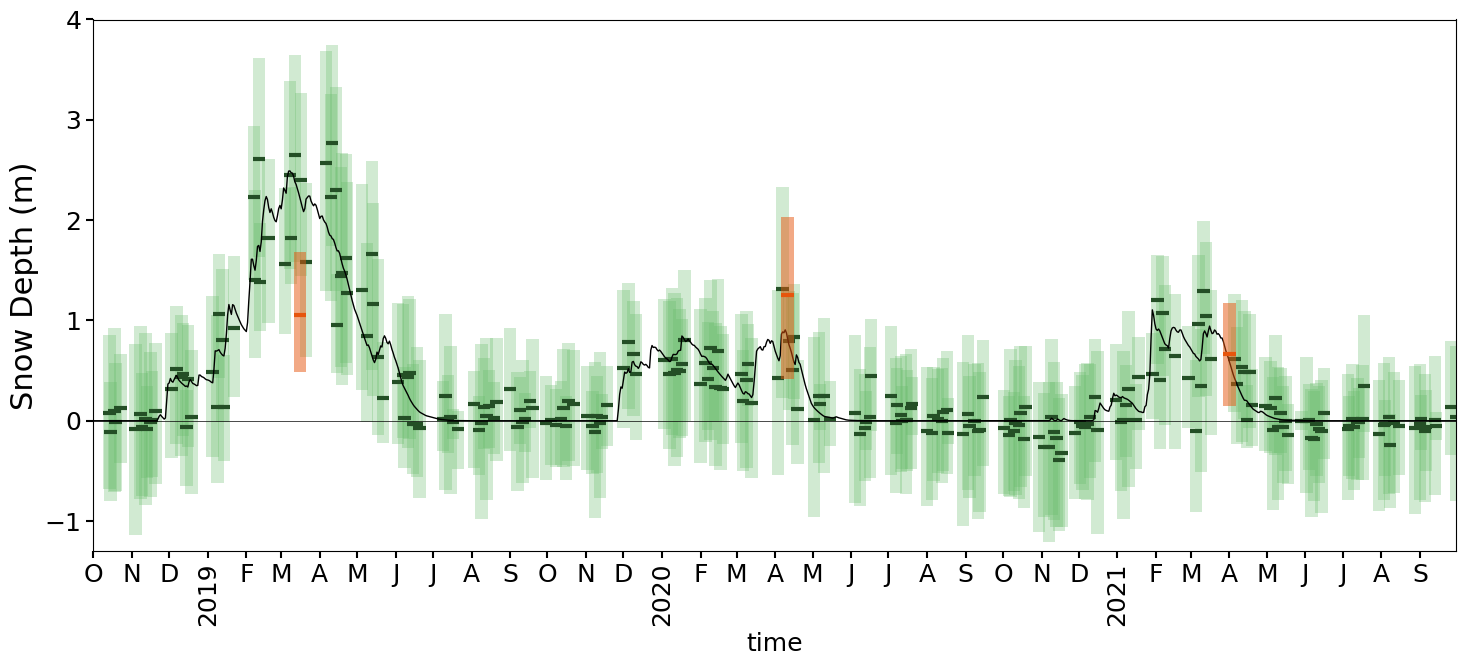

In [31]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf, col='icesat2_3dep_dif', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_icesat2_highlights.png', 
                         main_color=icesat2_color, main_color_median=icesat2_median_color, highlight_color=highlight_color, clim=(-1.3, 4))

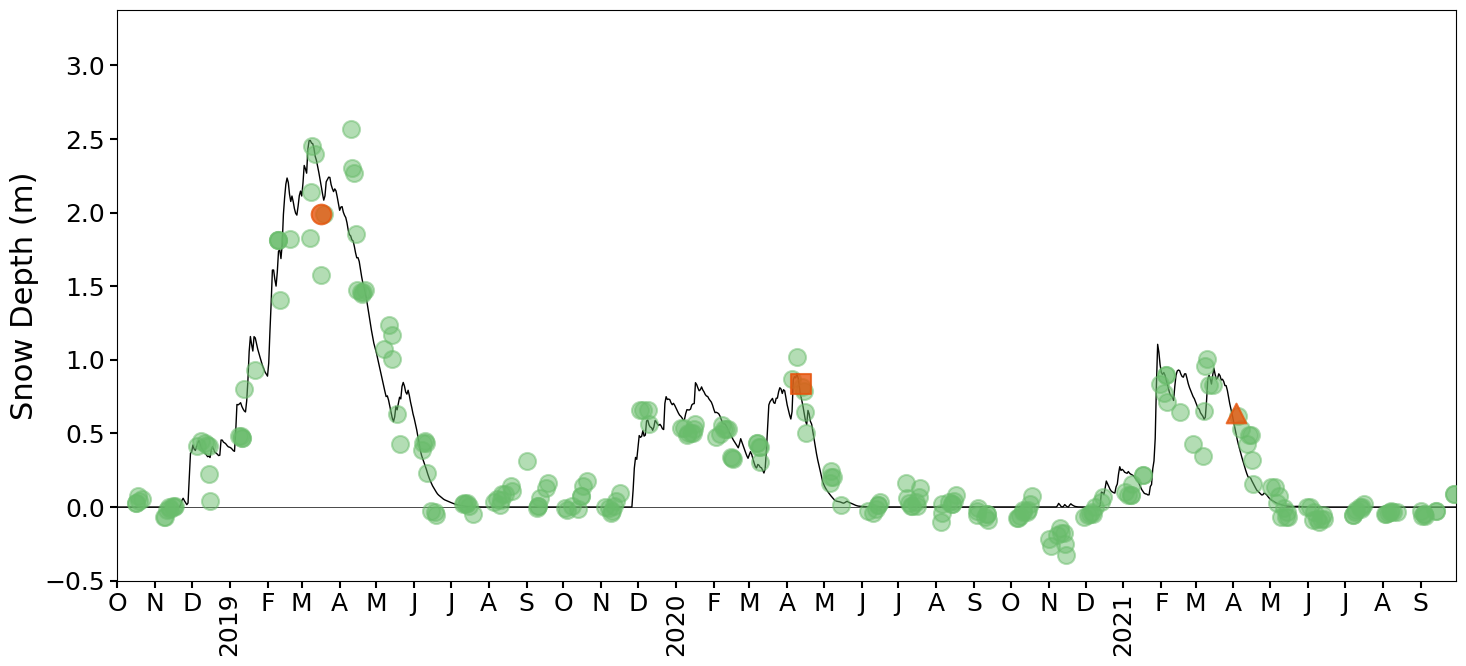

In [33]:
plt.rcParams['font.size'] = '18'

medians_dates = pd.to_datetime(medians_both['date'])
is_highlight = medians_dates.isin(highlight_dates_dt)

fig, ax = plt.subplots(figsize=(15, 7))

median_sd.plot(ax=ax, label='Spatial Median Reanalysis SD', color='k', linewidth=1)
# sd_rolling_10days_df.set_index('date')['sd_rolling_10days'].plot(
#     ax=ax, label='10-day Rolling Median Reanalysis SD', color='grey', linestyle='--', linewidth=2)

ax.scatter(medians_both.loc[~is_highlight, 'running_median_10days_date'],
           medians_both.loc[~is_highlight, 'running_median_10days'],
           color=icesat2_color, edgecolors=icesat2_color, linewidths=1.5, s=150, alpha=0.5,
           zorder=3, label='10-day Running Median ICESat-2')

# Plot each highlight date with year-matched marker shape
year_markers = {'2019': 'o', '2020': 's', '2021': '^'}
for date, marker in zip(highlight_dates_dt, [year_markers[str(d.year)] for d in highlight_dates_dt]):
    mask = medians_dates == date
    ax.scatter(medians_both.loc[mask, 'running_median_10days_date'],
               medians_both.loc[mask, 'running_median_10days'],
               color=highlight_color, linewidths=1.5, s=200, alpha=0.8, #edgecolors=highlight_color, 'goldenrod'
               zorder=4, marker=marker, label=f'Highlight {date.year}')

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_xlabel('')
ax.set_xlim([dt_min_plot, dt_max_plot])

months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months)
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')

for label in ax.get_xticklabels(which='major'):
    label.set(rotation=90, horizontalalignment='center')

ax.set_title('') #Median Snow Depth vs ICESat-2 Running Median
#ax.legend()
plt.tight_layout()
plt.savefig('../../figures/atl06sr_highlights_symbols_running_median.png', dpi=500)


In [ ]:
# Build a lookup Series from median_sd.SD_Post indexed by date
median_sd_series = median_sd.to_series()
median_sd_series.index = pd.to_datetime(median_sd_series.index)

# Look up domain median SD for each rolling-median date
lookup_dates = pd.to_datetime(medians_both['date']).dt.normalize()
medians_both['domain_sd'] = lookup_dates.map(median_sd_series)

# Add year column for shape encoding (matched on 'date' column, not running_median_10days_date)
medians_both['year'] = pd.to_datetime(medians_both['date']).dt.year.astype(str)

def compute_metrics(df, is2_col, rean_col):
    vals = df[[is2_col, rean_col]].dropna()
    is2  = vals[is2_col]
    rean = vals[rean_col]
    bias = float(np.mean(is2 - rean))
    corr = float(np.corrcoef(is2, rean)[0, 1])
    rmse = float(np.sqrt(np.mean((is2 - rean) ** 2)))
    return pd.DataFrame({
        'metric':       [bias, corr, rmse],
        'metric_label': ['Median Difference', 'Correlation', 'RMSE'],
        'x_pos':        [1, 1, 1],
        'y_pos':        [0.1, -0.1, -0.3],
        'metric_2f':    [round(bias, 2), round(corr, 2), round(rmse, 2)],
    })

In [38]:
# Three-panel with larger axis fonts
TITLE_FS = 18
LABEL_FS = 15

def make_chart_lg(source, metrics, title, x_col, x_title, y_col, y_title):
    line_data = pd.DataFrame({'x': [0, 3], 'y': [0, 3]})
    date_strs = pd.to_datetime(source['date']).dt.strftime('%Y-%m-%d')
    nh = source[~date_strs.isin(highlight_dates)]
    h  = source[ date_strs.isin(highlight_dates)]
    # x spans ~3 units (0–3), y spans ~3.5 units (-0.5–3): match pixels-per-unit
    chart_w = 280
    chart_h = round(chart_w * (3.5 / 3.0))  # fixed ratio so all panels are identical
    base = alt.layer(
        alt.Chart(nh).mark_point(size=60, color='darkgrey', filled=True).encode(
            x=alt.X(f'{x_col}:Q', axis=alt.Axis(title=x_title, titleFontSize=TITLE_FS, labelFontSize=LABEL_FS, titleFontWeight='normal')),
            y=alt.Y(f'{y_col}:Q', axis=alt.Axis(title=y_title, titleFontSize=TITLE_FS, labelFontSize=LABEL_FS, titleFontWeight='normal'))
        ),
        alt.Chart(line_data).mark_line(color='black', strokeDash=[5, 5]).encode(
            x='x:Q', y='y:Q'
        ),
        alt.Chart(metrics).mark_text(align='left', baseline='middle', dx=5, fontSize=LABEL_FS
        ).transform_calculate(
            annotation_text="datum.metric_label + ': ' + datum.metric_2f"
        ).encode(
            x=alt.X('x_pos:Q'), y=alt.Y('y_pos:Q'), text='annotation_text:N'
        )
    )
    highlights = alt.Chart(h).mark_point(
        size=120, filled=True, stroke=highlight_color, strokeWidth=2
    ).encode(
        x=alt.X(f'{x_col}:Q'),
        y=alt.Y(f'{y_col}:Q'),
        shape=alt.Shape('year:N', scale=alt.Scale(
            domain=['2019', '2020', '2021'],
            range=['circle', 'square', 'triangle-up']
        ), legend=alt.Legend(title='Year')),
        color=alt.value(highlight_color),
    )
    return (base + highlights).properties(width=chart_w, height=chart_h)

dec_jun_mask = pd.to_datetime(medians_both['date']).dt.month.isin([12, 1, 2, 3, 4, 5, 6])
source_dj = medians_both[dec_jun_mask]

src_left   = source_dj.dropna(subset=['icesat2_3dep_dif', 'reanalysis_sd'])
src_mid    = source_dj.dropna(subset=['icesat2_3dep_dif', 'domain_sd'])
src_right  = source_dj.dropna(subset=['running_median_10days', 'domain_sd'])

m_left  = compute_metrics(src_left,'icesat2_3dep_dif','reanalysis_sd')
m_mid   = compute_metrics(src_mid, 'icesat2_3dep_dif', 'domain_sd',              )
m_right = compute_metrics(src_right, 'running_median_10days', 'domain_sd')

c_left  = make_chart_lg(src_left,  m_left,  'IS2 Daily vs Sampled Reanalysis (Dec–Jun)',
                         'reanalysis_sd',          'Collocated WUS-SR Snow Depth (m)',
                         'icesat2_3dep_dif',      'ATL06-SR Median Snow Depth (m)')
c_mid   = make_chart_lg(src_mid,   m_mid,   'IS2 Daily vs Domain Median SD (Dec–Jun)',
                         'domain_sd',              'Domain Median WUS-SR Snow Depth (m)',
                         'icesat2_3dep_dif',      'ATL06-SR Median Snow Depth (m)')
c_right = make_chart_lg(src_right, m_right, 'IS2 10-day Rolling vs Domain Median SD (Dec–Jun)',
                         'domain_sd',              'Domain Median WUS-SR Snow Depth (m)',
                         'running_median_10days', 'ATL06-SR 10-day Rolling Median (m)')

combined = alt.hconcat(c_left, c_mid, c_right)
combined.save('../../figures/scatter_is2_reanalysis_3panel_dec_jun.png', ppi=500)
combined

alt.HConcatChart(...)

### Plot spatial location of highlight dates and their contributing acquisition dates for the 10-day running median:

Highlight date: 2019-03-16
Contributing dates (3):
  2019-03-12
  2019-03-17
  2019-03-21


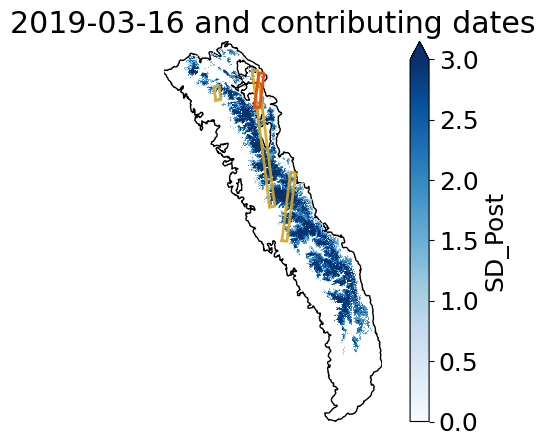

In [ ]:
from shapely.geometry import MultiPoint
from shapely import affinity

highlight_index = 0
focus_date = highlight_dates_dt[highlight_index]
window_half = pd.Timedelta('5D')
scalex=1.3
scaley=1

# Oriented bounding box for the highlight date
df_h = atl06sr_gdf[(atl06sr_gdf['acqdate_dt'] == highlight_dates[highlight_index])]
region_box = affinity.scale(
    MultiPoint(list(zip(df_h.geometry.x, df_h.geometry.y))).minimum_rotated_rectangle,
    xfact=scalex, yfact=scaley)
region_lon, region_lat = region_box.exterior.xy

# Contributing dates: within ±5 days of the highlight date (excluding it)
all_acqdates = pd.to_datetime(atl06sr_gdf['acqdate_dt'].unique())
contributing_dates = all_acqdates[(abs(all_acqdates - focus_date) <= window_half) & (all_acqdates != focus_date)]

fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds_roi.SD_Post.sel(time=focus_date).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)



# Contributing date oriented boxes
for contrib_date in contributing_dates:
    df_c = atl06sr_gdf[(atl06sr_gdf['acqdate_dt'] == contrib_date.strftime('%Y-%m-%d'))]
    if df_c.empty:
        continue
    c_box = affinity.scale(
        MultiPoint(list(zip(df_c.geometry.x, df_c.geometry.y))).minimum_rotated_rectangle,
        xfact=scalex, yfact=scaley)
    c_lon, c_lat = c_box.exterior.xy
    ax.plot(c_lon, c_lat, linewidth=2, color='goldenrod', alpha=0.9)

# Highlight date oriented box
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)

ax.set_axis_off()
ax.set_title(f'{highlight_dates[highlight_index]} and contributing dates')
plt.tight_layout()

print(f'Highlight date: {highlight_dates[highlight_index]}')
print(f'Contributing dates ({len(contributing_dates)}):')
for d in sorted(contributing_dates):
    print(f'  {d.date()}')

plt.savefig(f'../../figures/sierra_map_highlight_contributors_{highlight_index}.png', dpi=500)

Highlight date: 2020-04-11
Contributing dates (4):
  2020-04-07
  2020-04-12
  2020-04-15
  2020-04-16


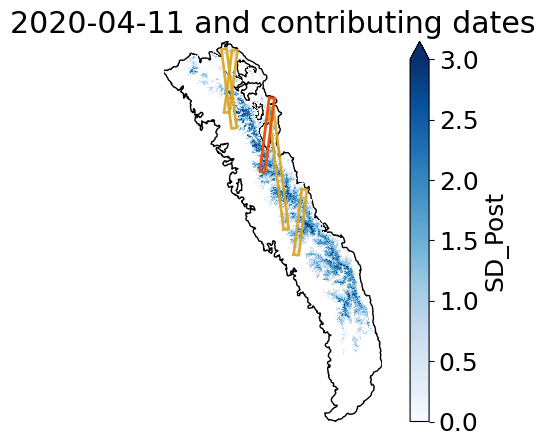

In [40]:
from shapely.geometry import MultiPoint
from shapely import affinity

highlight_index = 1
focus_date = highlight_dates_dt[highlight_index]
window_half = pd.Timedelta('5D')
scalex=1.3
scaley=1

# Oriented bounding box for the highlight date
df_h = atl06sr_gdf[(atl06sr_gdf['acqdate_dt'] == highlight_dates[highlight_index])]
region_box = affinity.scale(
    MultiPoint(list(zip(df_h.geometry.x, df_h.geometry.y))).minimum_rotated_rectangle,
    xfact=scalex, yfact=scaley)
region_lon, region_lat = region_box.exterior.xy

# Contributing dates: within ±5 days of the highlight date (excluding it)
all_acqdates = pd.to_datetime(atl06sr_gdf['acqdate_dt'].unique())
contributing_dates = all_acqdates[(abs(all_acqdates - focus_date) <= window_half) & (all_acqdates != focus_date)]

fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds_roi.SD_Post.sel(time=focus_date).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)



# Contributing date oriented boxes
for contrib_date in contributing_dates:
    df_c = atl06sr_gdf[(atl06sr_gdf['acqdate_dt'] == contrib_date.strftime('%Y-%m-%d'))]
    if df_c.empty:
        continue
    c_box = affinity.scale(
        MultiPoint(list(zip(df_c.geometry.x, df_c.geometry.y))).minimum_rotated_rectangle,
        xfact=scalex, yfact=scaley)
    c_lon, c_lat = c_box.exterior.xy
    ax.plot(c_lon, c_lat, linewidth=2, color='goldenrod', alpha=0.9)

# Highlight date oriented box
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)

ax.set_axis_off()
ax.set_title(f'{highlight_dates[highlight_index]} and contributing dates')
plt.tight_layout()

print(f'Highlight date: {highlight_dates[highlight_index]}')
print(f'Contributing dates ({len(contributing_dates)}):')
for d in sorted(contributing_dates):
    print(f'  {d.date()}')

plt.savefig(f'../../figures/sierra_map_highlight_contributors_{highlight_index}.png', dpi=500)

Highlight date: 2021-04-01
Contributing dates (1):
  2021-04-05


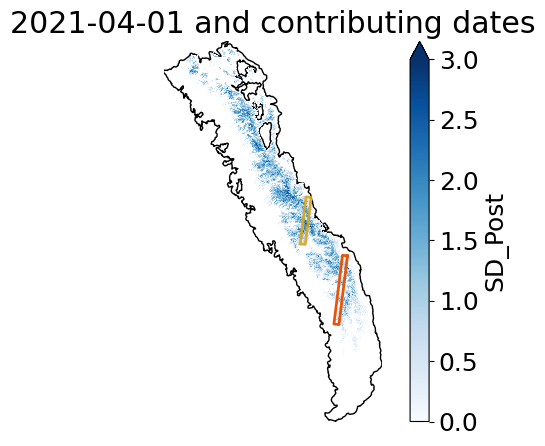

In [41]:
from shapely.geometry import MultiPoint
from shapely import affinity

highlight_index = 2
focus_date = highlight_dates_dt[highlight_index]
window_half = pd.Timedelta('5D')
scalex=1.3
scaley=1

# Oriented bounding box for the highlight date
df_h = atl06sr_gdf[(atl06sr_gdf['acqdate_dt'] == highlight_dates[highlight_index])]
region_box = affinity.scale(
    MultiPoint(list(zip(df_h.geometry.x, df_h.geometry.y))).minimum_rotated_rectangle,
    xfact=scalex, yfact=scaley)
region_lon, region_lat = region_box.exterior.xy

# Contributing dates: within ±5 days of the highlight date (excluding it)
all_acqdates = pd.to_datetime(atl06sr_gdf['acqdate_dt'].unique())
contributing_dates = all_acqdates[(abs(all_acqdates - focus_date) <= window_half) & (all_acqdates != focus_date)]

fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds_roi.SD_Post.sel(time=focus_date).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)



# Contributing date oriented boxes
for contrib_date in contributing_dates:
    df_c = atl06sr_gdf[(atl06sr_gdf['acqdate_dt'] == contrib_date.strftime('%Y-%m-%d'))]
    if df_c.empty:
        continue
    c_box = affinity.scale(
        MultiPoint(list(zip(df_c.geometry.x, df_c.geometry.y))).minimum_rotated_rectangle,
        xfact=scalex, yfact=scaley)
    c_lon, c_lat = c_box.exterior.xy
    ax.plot(c_lon, c_lat, linewidth=2, color='goldenrod', alpha=0.9)

# Highlight date oriented box
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)

ax.set_axis_off()
ax.set_title(f'{highlight_dates[highlight_index]} and contributing dates')
plt.tight_layout()

print(f'Highlight date: {highlight_dates[highlight_index]}')
print(f'Contributing dates ({len(contributing_dates)}):')
for d in sorted(contributing_dates):
    print(f'  {d.date()}')

plt.savefig(f'../../figures/sierra_map_highlight_contributors_{highlight_index}.png', dpi=500)

## Bonus figure: snow depth by elevation for the three highlight dates:

In [43]:
sierras_dem = xr.open_dataset('../../data/misc/dem_200m_sierras.nc')
sierras_dem = sierras_dem.rio.write_crs('epsg:4326')
dem_sierras = sierras_dem.rio.clip(sierras.geometry)

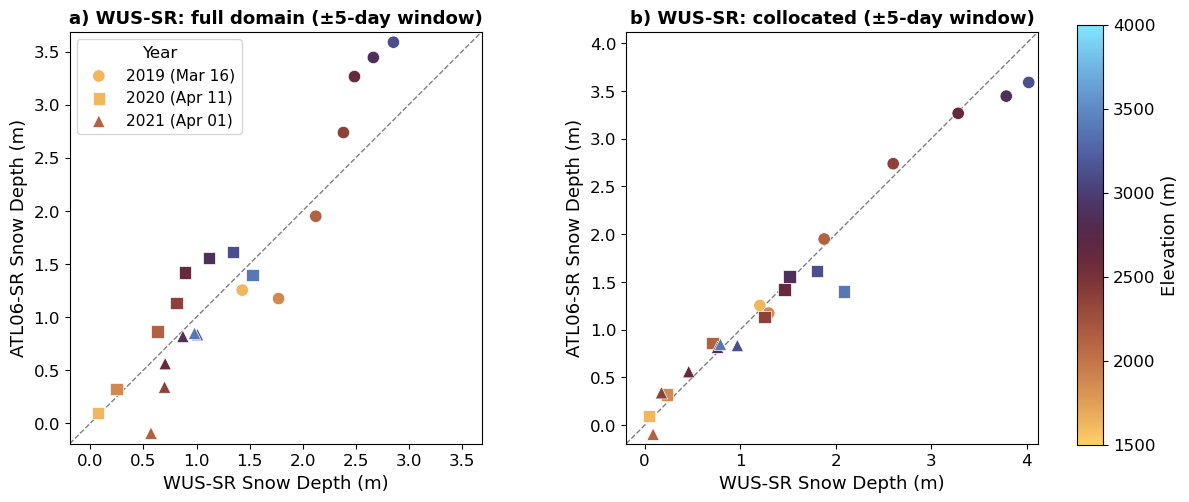

In [45]:
# === Scatter: ATL06-SR vs WUS-SR snow depth by elevation band, 3 highlight dates ===
# Left panel:  WUS-SR from full gridded domain on exact highlight date
# Right panel: WUS-SR collocated at ATL06-SR points within the ±5-day window
# ATL06-SR (y-axis) is the same in both panels: ±5-day window, median per elevation band

window_half = pd.Timedelta('5D')
elev_bins   = np.arange(1500, 4250, 250)
elev_mids   = (elev_bins[:-1] + elev_bins[1:]) / 2

cmap_elev = plt.cm.managua
norm_elev = plt.Normalize(vmin=elev_bins[0], vmax=elev_bins[-1])
year_markers_plt = {'2019': 'o', '2020': 's', '2021': '^'}
year_labels      = {'2019': '2019 (Mar 16)', '2020': '2020 (Apr 11)', '2021': '2021 (Apr 01)'}

# Regrid 200 m DEM to WUS-SR grid once
dem_on_wus    = sierras_dem.elevation.interp(y=swe_sca_ds.y, x=swe_sca_ds.x, method='linear').values
elev_flat_all = dem_on_wus.flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

for h_date in highlight_dates_dt:
    yr     = str(h_date.year)
    marker = year_markers_plt[yr]

    # --- ATL06-SR: ±5-day window, median per elevation band (shared by both panels) ---
    is2_window = atl06sr_gdf[abs(atl06sr_gdf['acqdate_dt'] - h_date) <= window_half].copy()
    is2_window['elev_band'] = pd.cut(is2_window['h_mean'], bins=elev_bins, labels=elev_mids)
    is2_stats = is2_window.groupby('elev_band', observed=True)['icesat2_3dep_dif'].agg(['median', 'count'])
    is2_elev  = is2_stats.loc[is2_stats['count'] >= 100, 'median']

    # --- LEFT: WUS-SR full gridded domain, all dates in the ±5-day window ---
    wus_window = swe_sca_ds_roi.SD_Post.sel(
        time=slice(h_date - window_half, h_date + window_half)
    ).values  # shape: (n_dates, n_y, n_x)
    n_dates   = wus_window.shape[0]
    wus_flat  = wus_window.reshape(n_dates, -1).flatten()
    elev_rep  = np.tile(elev_flat_all, n_dates)
    valid     = np.isfinite(wus_flat) & np.isfinite(elev_rep)
    wus_df    = pd.DataFrame({'elev': elev_rep[valid], 'wus_sd': wus_flat[valid]})
    wus_df['elev_band'] = pd.cut(wus_df['elev'], bins=elev_bins, labels=elev_mids)
    wus_stats = wus_df.groupby('elev_band', observed=True)['wus_sd'].agg(['median', 'count'])
    wus_elev  = wus_stats.loc[wus_stats['count'] >= 100, 'median']

    shared = is2_elev.index.intersection(wus_elev.index)
    x1, y1 = wus_elev[shared].values.astype(float), is2_elev[shared].values.astype(float)
    e1     = shared.astype(float)
    ok     = np.isfinite(x1) & np.isfinite(y1)
    ax1.scatter(x1[ok], y1[ok], c=e1[ok], cmap=cmap_elev, norm=norm_elev,
                marker=marker, s=80, edgecolors='white', linewidths=0.5, zorder=3,
                label=year_labels[yr])

    # --- RIGHT: WUS-SR collocated at ATL06-SR points within the ±5-day window ---
    is2_window['elev_band'] = pd.cut(is2_window['h_mean'], bins=elev_bins, labels=elev_mids)
    wus_col_stats = is2_window.groupby('elev_band', observed=True)['reanalysis_sd'].agg(['median', 'count'])
    wus_col_elev  = wus_col_stats.loc[wus_col_stats['count'] >= 100, 'median']

    shared2 = is2_elev.index.intersection(wus_col_elev.index)
    x2, y2  = wus_col_elev[shared2].values.astype(float), is2_elev[shared2].values.astype(float)
    e2      = shared2.astype(float)
    ok2     = np.isfinite(x2) & np.isfinite(y2)
    ax2.scatter(x2[ok2], y2[ok2], c=e2[ok2], cmap=cmap_elev, norm=norm_elev,
                marker=marker, s=80, edgecolors='white', linewidths=0.5, zorder=3,
                label=year_labels[yr])

# 1:1 lines and formatting
for ax, title in [(ax1, 'a) WUS-SR: full domain (±5-day window)'),
                  (ax2, 'b) WUS-SR: collocated (±5-day window)')]:
    pts = np.vstack([c.get_offsets() for c in ax.collections if len(c.get_offsets())])
    lim = [pts.min() - 0.1, pts.max() + 0.1]
    ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, zorder=0)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel('WUS-SR Snow Depth (m)', fontsize=13)
    ax.set_ylabel('ATL06-SR Snow Depth (m)', fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=12)

ax1.legend(title='Year', fontsize=11, title_fontsize=12)

fig.subplots_adjust(right=0.87, wspace=0.35)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
sm      = plt.cm.ScalarMappable(cmap=cmap_elev, norm=norm_elev)
cbar    = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Elevation (m)', fontsize=13)
cbar.ax.tick_params(labelsize=12)
plt.savefig('../../figures/scatter_is2_wussr_elev_bands_highlight.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()


## And for all acquisition dates:

### Generalize the elevation-band comparison to all acquisition dates:

In [49]:
# Rather than slicing the full grid separately for each acquisition date's
# +/-5-day window (which re-reads heavily overlapping days many times over
# 260+ dates), reduce median SD by elevation band ONCE for every day in the
# record, then look up cheap +/-5-day windows into that small (time, elev_band)
# array per acquisition date.

# Elevation on the WUS-SR grid (same interpolation used above)
elev_da = sierras_dem.elevation.interp(y=swe_sca_ds.y, x=swe_sca_ds.x, method='linear')

# Restrict to the period actually covered by ICESat-2 acquisitions (+/- window padding)
acq_dates_all = pd.to_datetime(sorted(atl06sr_gdf['acqdate_dt'].unique()))
time_start = acq_dates_all.min() - window_half
time_end   = acq_dates_all.max() + window_half
sd_roi_period = swe_sca_ds_roi['SD_Post'].sel(time=slice(time_start, time_end))

# Stack spatial dims and attach elevation as a coordinate for binning
sd_stacked = sd_roi_period.stack(points=('y', 'x'))
sd_stacked = sd_stacked.assign_coords(
    elevation=('points', elev_da.stack(points=('y', 'x')).values)
)

# One-pass reduction: median SD per elevation band, for every day in the record
sd_by_elev_band = (
    sd_stacked
    .groupby_bins('elevation', bins=elev_bins, labels=elev_mids)
    .median(skipna=True)
    .compute()
    .rename({'elevation_bins': 'elev_band'})
)
sd_by_elev_band

<xarray.DataArray 'SD_Post' (time: 1088, elev_band: 10)> Size: 44kB
array([[0.    , 0.    , 0.    , ..., 0.    , 0.0024, 0.013 ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.0018, 0.0094],
       [0.    , 0.    , 0.    , ..., 0.0002, 0.002 , 0.0088],
       ...,
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ]],
      shape=(1088, 10), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 9kB 2018-10-09 2018-10-10 ... 2021-09-30
    spatial_ref  int64 8B 0
  * elev_band    (elev_band) float64 80B 1.625e+03 1.875e+03 ... 3.875e+03
Attributes:
    Units:    meters

In [50]:
# Per-acquisition-date elevation-band medians: ATL06-SR vs both WUS-SR variants
# Restrict to December-June to exclude snow-off periods
acq_dates_dj = acq_dates_all[acq_dates_all.month.isin([12, 1, 2, 3, 4, 5, 6])]

records = []

for acq_date in acq_dates_dj:
    window = atl06sr_gdf[abs(atl06sr_gdf['acqdate_dt'] - acq_date) <= window_half].copy()
    window['elev_band'] = pd.cut(window['h_mean'], bins=elev_bins, labels=elev_mids)

    is2_stats = window.groupby('elev_band', observed=True)['icesat2_3dep_dif'].agg(['median', 'count'])
    is2_elev  = is2_stats.loc[is2_stats['count'] >= 100, 'median']

    wus_col_stats = window.groupby('elev_band', observed=True)['reanalysis_sd'].agg(['median', 'count'])
    wus_col_elev  = wus_col_stats.loc[wus_col_stats['count'] >= 100, 'median']

    # Cheap lookup into the precomputed (time, elev_band) array instead of re-reading the grid
    wus_full_elev = sd_by_elev_band.sel(
        time=slice(acq_date - window_half, acq_date + window_half)
    ).median(dim='time', skipna=True).to_series()

    for band in is2_elev.index:
        records.append({
            'acqdate':               acq_date,
            'elev_band':             float(band),
            'is2_median':            is2_elev.get(band, np.nan),
            'wus_full_median':       wus_full_elev.get(float(band), np.nan),
            'wus_collocated_median': wus_col_elev.get(band, np.nan),
        })

elev_band_all_dates = pd.DataFrame.from_records(records).dropna(subset=['is2_median'])
elev_band_all_dates['year'] = elev_band_all_dates['acqdate'].dt.year.astype(str)
elev_band_all_dates['is_highlight'] = elev_band_all_dates['acqdate'].isin(highlight_dates_dt)
elev_band_all_dates

,acqdate,elev_band,is2_median,wus_full_median,wus_collocated_median,year,is_highlight
0,2018-12-03,2125.0,-0.107568,0.2938,0.310709,2018,False
1,2018-12-03,2375.0,0.241492,0.4836,0.375640,2018,False
2,2018-12-03,2625.0,0.365112,0.5150,0.382669,2018,False
3,2018-12-03,2875.0,0.437692,0.5636,0.384109,2018,False
4,2018-12-03,3125.0,0.723766,0.6134,0.667116,2018,False
...,...,...,...,...,...,...,...
1016,2021-06-16,1625.0,0.031973,0.0000,0.000000,2021,False
1017,2021-06-16,1875.0,-0.129547,0.0000,0.000000,2021,False
1018,2021-06-16,2125.0,-0.157100,0.0000,0.000504,2021,False
1019,2021-06-16,2375.0,0.080650,0.0000,0.013882,2021,False


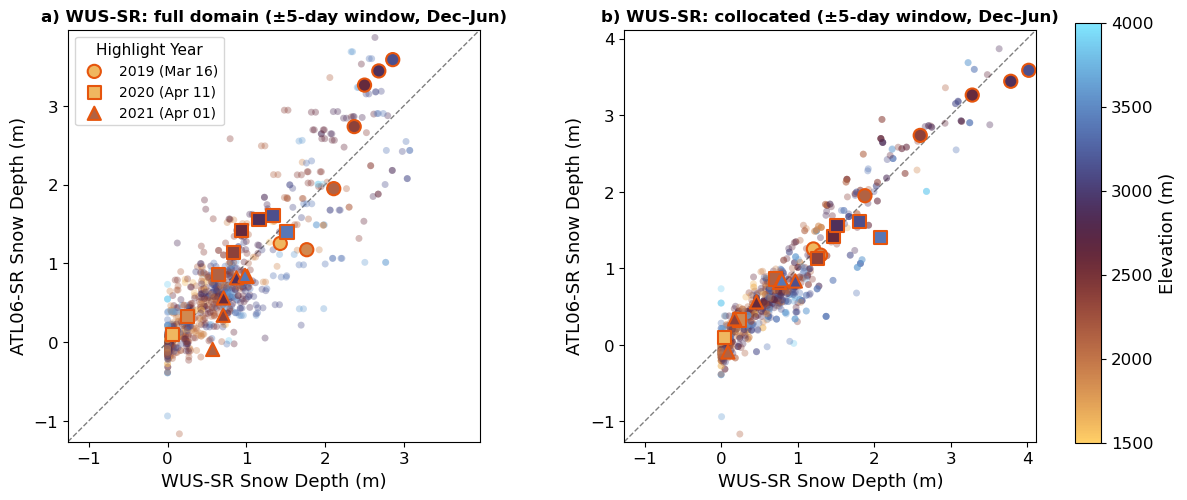

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

nh = elev_band_all_dates[~elev_band_all_dates['is_highlight']]
h  = elev_band_all_dates[ elev_band_all_dates['is_highlight']]

panels = [
    (ax1, 'wus_full_median',       'a) WUS-SR: full domain (±5-day window, Dec–Jun)'),
    (ax2, 'wus_collocated_median', 'b) WUS-SR: collocated (±5-day window, Dec–Jun)'),
]

for ax, wus_col, title in panels:
    pts = nh.dropna(subset=[wus_col, 'is2_median'])
    ax.scatter(pts[wus_col], pts['is2_median'], c=pts['elev_band'], cmap=cmap_elev, norm=norm_elev,
               s=25, alpha=0.35, edgecolors='none', zorder=2)

    for yr, marker in year_markers_plt.items():
        hp = h.loc[h['year'] == yr].dropna(subset=[wus_col, 'is2_median'])
        ax.scatter(hp[wus_col], hp['is2_median'], c=hp['elev_band'], cmap=cmap_elev, norm=norm_elev,
                   marker=marker, s=90, edgecolors=highlight_color, linewidths=1.5, zorder=3,
                   label=year_labels[yr])

    all_vals = pd.concat([pts[wus_col], pts['is2_median']])
    lim = [all_vals.min() - 0.1, all_vals.max() + 0.1]
    ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, zorder=0)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel('WUS-SR Snow Depth (m)', fontsize=13)
    ax.set_ylabel('ATL06-SR Snow Depth (m)', fontsize=13)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=12)

ax1.legend(title='Highlight Year', fontsize=10, title_fontsize=11)

fig.subplots_adjust(right=0.87, wspace=0.35)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
sm      = plt.cm.ScalarMappable(cmap=cmap_elev, norm=norm_elev)
cbar    = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Elevation (m)', fontsize=13)
cbar.ax.tick_params(labelsize=12)
plt.savefig('../../figures/scatter_is2_wussr_elev_bands_alldates.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()